# Rule-Based Chatbot — 01 Exploring the Intents

A **retrieval-based intent chatbot**: it matches a user message to the closest known *intent* (greeting, hours, payments, returns, …) and replies with that intent's canned response. The knowledge base is an `intents.json` of example patterns + responses. This notebook explores it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import utils

intents=utils.load_intents()
df=utils.intents_to_frame(intents)
print('intents:',len(intents),'| example patterns:',len(df))
df.head()

intents: 12 | example patterns: 77


,pattern,tag
0,hi,greeting
1,hello,greeting
2,hey,greeting
3,good morning,greeting
4,good evening,greeting


## 1. Patterns per intent

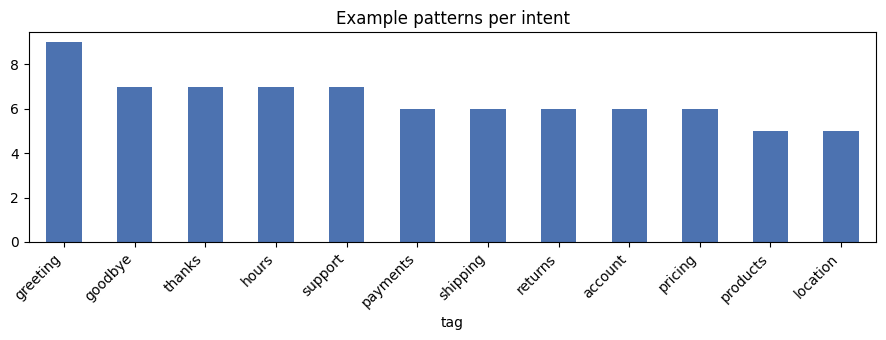

tag
greeting    9
goodbye     7
thanks      7
hours       7
support     7
payments    6
shipping    6
returns     6
account     6
pricing     6
products    5
location    5


In [2]:
vc=df['tag'].value_counts()
fig,ax=plt.subplots(figsize=(9,3.5)); vc.plot(kind='bar',ax=ax,color='#4c72b0'); ax.set_title('Example patterns per intent'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(vc.to_string())

## 2. Example intents and responses

In [3]:
for it in intents[:4]:
    print('TAG:',it['tag'])
    print('  patterns :',it['patterns'][:3])
    print('  responses:',it['responses'][:1],'\n')

TAG: greeting
  patterns : ['hi', 'hello', 'hey']
  responses: ['Hello! How can I help you today?'] 

TAG: goodbye
  patterns : ['bye', 'goodbye', 'see you later']
  responses: ['Goodbye! Have a great day.'] 

TAG: thanks
  patterns : ['thanks', 'thank you', "that's helpful"]
  responses: ["You're welcome!"] 

TAG: hours
  patterns : ['what are your hours', 'when are you open', 'opening hours']
  responses: ['We are open Monday to Friday, 9am to 6pm.'] 



## 3. Summary

- **12 intents, 77 example patterns** (~6 each).
- The chatbot will TF-IDF-vectorize these patterns and match a user message to the nearest one. Notebook 02 builds it; 03 evaluates how well it generalises to unseen phrasings.